In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure notebook to display all plots cleanly inline
%matplotlib inline

# Apply a clean data science theme for visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup completed successfully. Ready to load data!")

Setup completed successfully. Ready to load data!


In [3]:



df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")




In [4]:
# Display initial rows to see structure
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:


# 1. Clean hidden trailing/leading spaces from column names (Common Kaggle layout issue)
print("Columns before cleaning:", df.columns.tolist())
df.columns = df.columns.str.strip()
print("Columns after stripping whitespace:", df.columns.tolist())

# 2. Parse dates natively (Kaggle date format is usually DD-MM-YYYY)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 3. Feature engineering: Extract components for temporal/seasonal trend analysis
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Month_Num'] = df['Date'].dt.month

print("\n--- Cleaned Structural Summary ---")
df.info()

Columns before cleaning: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']
Columns after stripping whitespace: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

--- Cleaned Structural Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    str           
 1   Date                                     267 non-null    datetime64[us]
 2   Frequency                                267 non-null    str           
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4  

In [6]:

print("--- Statistical Distribution of Numeric Fields ---")
print(df.describe())

# Compute regional impact to see which states faced highest average unemployment in 2020
print("\n--- Top 10 Heavily Impacted Regions (Highest Mean Unemployment) ---")
regional_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(regional_stats.head(10))

--- Statistical Distribution of Numeric Fields ---
                             Date  Estimated Unemployment Rate (%)  \
count                         267                       267.000000   
mean   2020-06-16 09:15:30.337078                        12.236929   
min           2020-01-31 00:00:00                         0.500000   
25%           2020-03-31 00:00:00                         4.845000   
50%           2020-06-30 00:00:00                         9.650000   
75%           2020-08-31 00:00:00                        16.755000   
max           2020-10-31 00:00:00                        75.850000   
std                           NaN                        10.803283   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        2.670000e+02                               267.000000   
mean         1.396211e+07                                41.681573   
min          1.175420e+05                                16.770000   
25%          2.838930e+06             

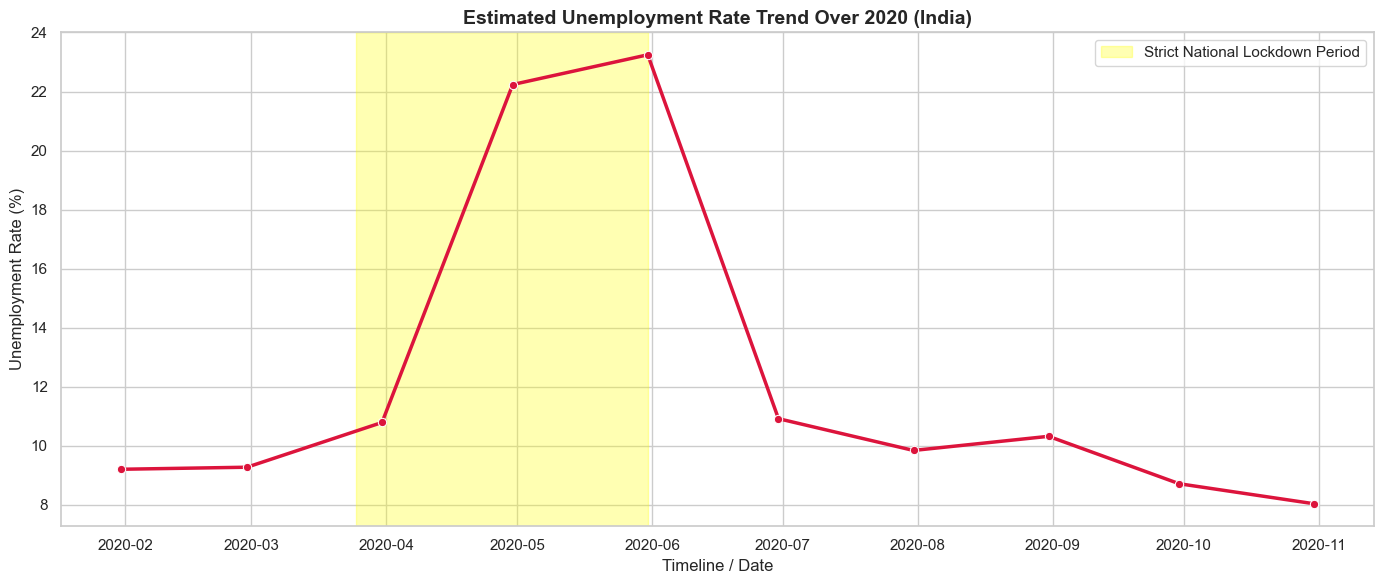

In [7]:

plt.figure(figsize=(14, 6))

# Plot national historical average change over months
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', errorbar=None, color='crimson', lw=2.5, marker='o')

# Highlight the strict nationwide lockdown window (late March to end of May 2020)
plt.axvspan('2020-03-25', '2020-05-31', color='yellow', alpha=0.3, label='Strict National Lockdown Period')

plt.title('Estimated Unemployment Rate Trend Over 2020 (India)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline / Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

C:\Users\Sabeel Khattak\AppData\Local\Temp\ipykernel_9988\3384062974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Estimated Unemployment Rate (%)', y='Region', palette='coolwarm')


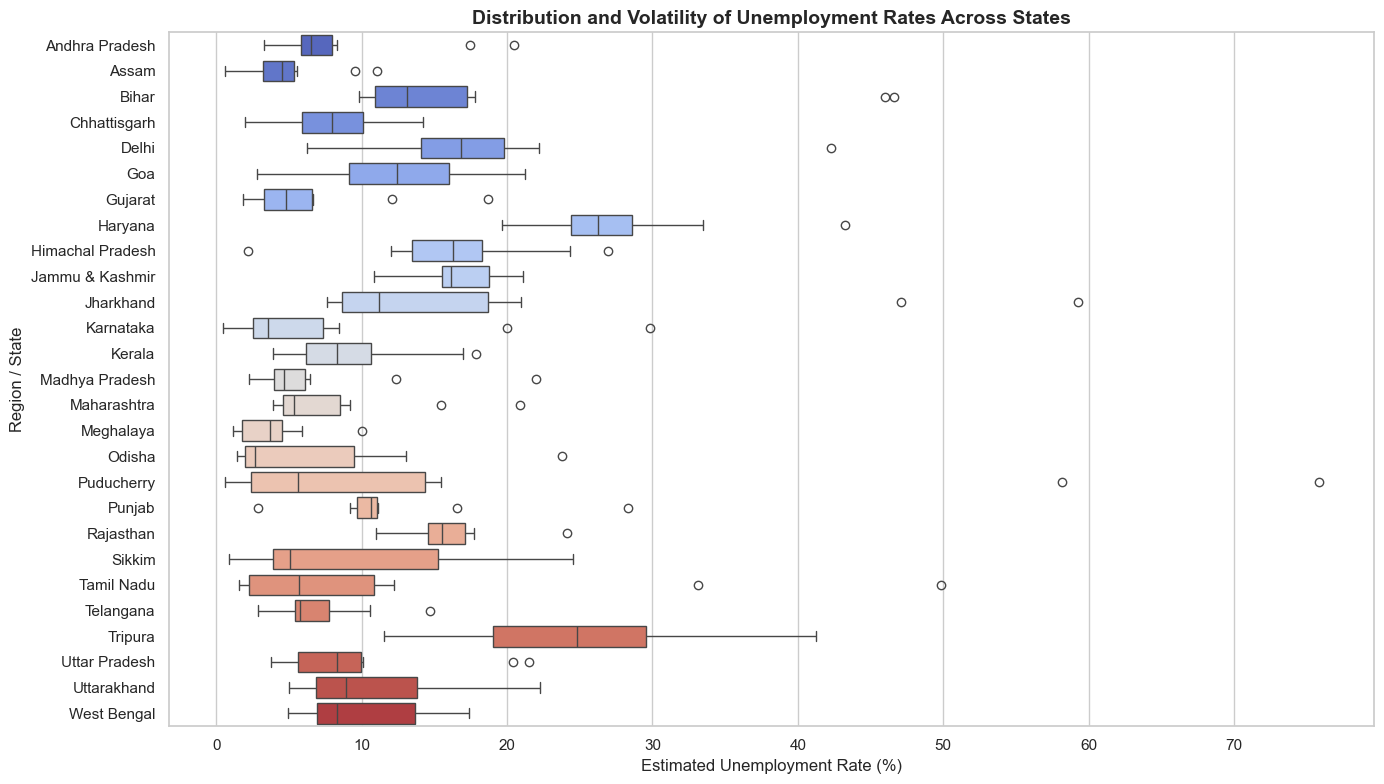

In [8]:


plt.figure(figsize=(14, 8))

# Boxplot helps identify variance, medians, and massive outlier spikes during extreme months
sns.boxplot(data=df, x='Estimated Unemployment Rate (%)', y='Region', palette='coolwarm')

plt.title('Distribution and Volatility of Unemployment Rates Across States', fontsize=14, fontweight='bold')
plt.xlabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.ylabel('Region / State', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\Sabeel Khattak\AppData\Local\Temp\ipykernel_9988\2359339482.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_monthly, x='Month_Name', y='Estimated Unemployment Rate (%)', palette='viridis')


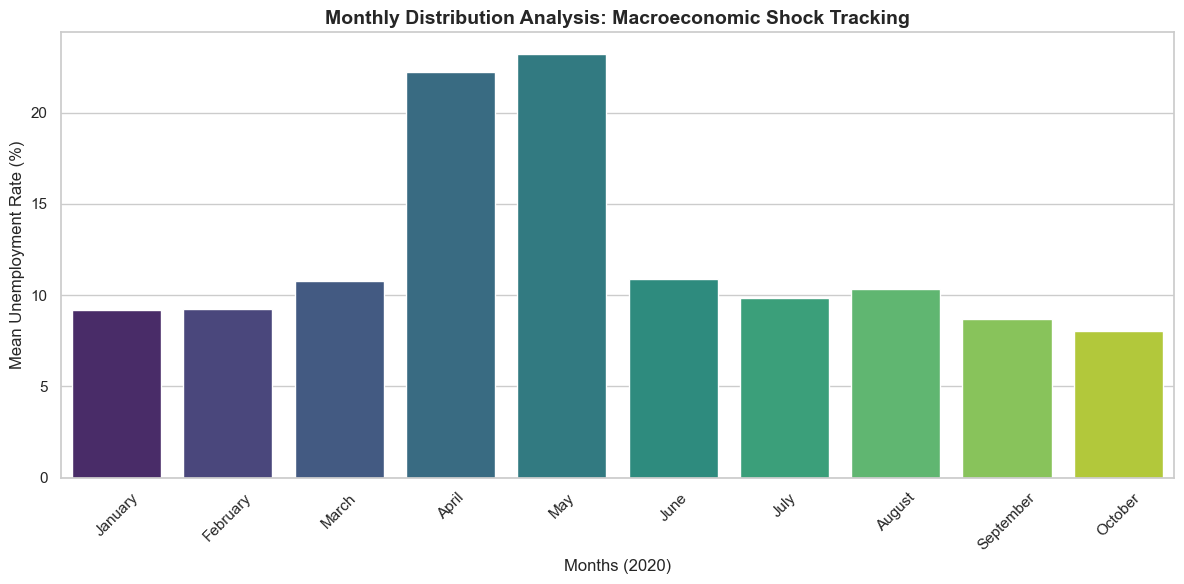


================== INSIGHTS FOR SUBMISSION REPORT ==================
-> Peak Lockdown Phase Mean Unemployment (April-May 2020): 22.75%
-> Rest of the Year Mean Unemployment: 9.63%
-> Narrative Conclusion: The strict containment phase induced an immediate economic standstill,
   visible in the sharp April/May spike. The subsequent decline highlights partial workforce recovery.


In [9]:


# Group by month components to get clear aggregate comparison steps
df_monthly = df.groupby(['Month_Num', 'Month_Name'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_monthly, x='Month_Name', y='Estimated Unemployment Rate (%)', palette='viridis')
plt.title('Monthly Distribution Analysis: Macroeconomic Shock Tracking', fontsize=14, fontweight='bold')
plt.xlabel('Months (2020)', fontsize=12)
plt.ylabel('Mean Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final numeric comparison text to read out during video
lockdown_avg = df[df['Date'].between('2020-04-01', '2020-05-31')]['Estimated Unemployment Rate (%)'].mean()
normal_avg = df[~df['Date'].between('2020-04-01', '2020-05-31')]['Estimated Unemployment Rate (%)'].mean()

print("\n================== INSIGHTS FOR SUBMISSION REPORT ==================")
print(f"-> Peak Lockdown Phase Mean Unemployment (April-May 2020): {lockdown_avg:.2f}%")
print(f"-> Rest of the Year Mean Unemployment: {normal_avg:.2f}%")
print("-> Narrative Conclusion: The strict containment phase induced an immediate economic standstill,")
print("   visible in the sharp April/May spike. The subsequent decline highlights partial workforce recovery.")